In [5]:
# importing all the libraries i need for this project
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [4]:
# loading the dataset into a dataframe
df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')

# checking the size of the dataset
print("rows and columns:", df.shape)

# looking at the first few rows to understand the data
print("\nfirst 5 rows:")
df.head()

rows and columns: (1470, 35)

first 5 rows:


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [6]:
# checking if there are any missing values
print("total missing values:", df.isnull().sum().sum())

# checking how many employees left vs stayed
print("\nhow many left vs stayed:")
print(df['Attrition'].value_counts())

# what percentage of employees left
print("\nattrition rate in %:")
print(df['Attrition'].value_counts(normalize=True)*100)

# converting yes/no to 1/0 for analysis
df['Attrition_Num'] = df['Attrition'].map({'Yes': 1, 'No': 0})

# dropping columns that are not useful
df = df.drop(['EmployeeCount', 'EmployeeNumber', 
              'Over18', 'StandardHours'], axis=1)

print("\nshape after cleaning:", df.shape)

total missing values: 0

how many left vs stayed:
Attrition
No     1233
Yes     237
Name: count, dtype: int64

attrition rate in %:
Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64

shape after cleaning: (1470, 32)


In [7]:
# i want to see which department has the most attrition
dept_attrition = df.groupby('Department')['Attrition_Num'].mean()*100
print("attrition rate by department:")
print(dept_attrition)

# checking attrition by age group
print("\nattrition by age:")
print(df.groupby('Attrition')['Age'].mean())

# checking attrition by job role
print("\nattrition by job role:")
print(df.groupby('JobRole')['Attrition_Num'].mean()*100)

# checking attrition by salary
print("\nattrition by monthly income:")
print(df.groupby('Attrition')['MonthlyIncome'].mean())

# checking attrition by years at company
print("\nattrition by years at company:")
print(df.groupby('Attrition')['YearsAtCompany'].mean())

attrition rate by department:
Department
Human Resources           19.047619
Research & Development    13.839750
Sales                     20.627803
Name: Attrition_Num, dtype: float64

attrition by age:
Attrition
No     37.561233
Yes    33.607595
Name: Age, dtype: float64

attrition by job role:
JobRole
Healthcare Representative     6.870229
Human Resources              23.076923
Laboratory Technician        23.938224
Manager                       4.901961
Manufacturing Director        6.896552
Research Director             2.500000
Research Scientist           16.095890
Sales Executive              17.484663
Sales Representative         39.759036
Name: Attrition_Num, dtype: float64

attrition by monthly income:
Attrition
No     6832.739659
Yes    4787.092827
Name: MonthlyIncome, dtype: float64

attrition by years at company:
Attrition
No     7.369019
Yes    5.130802
Name: YearsAtCompany, dtype: float64


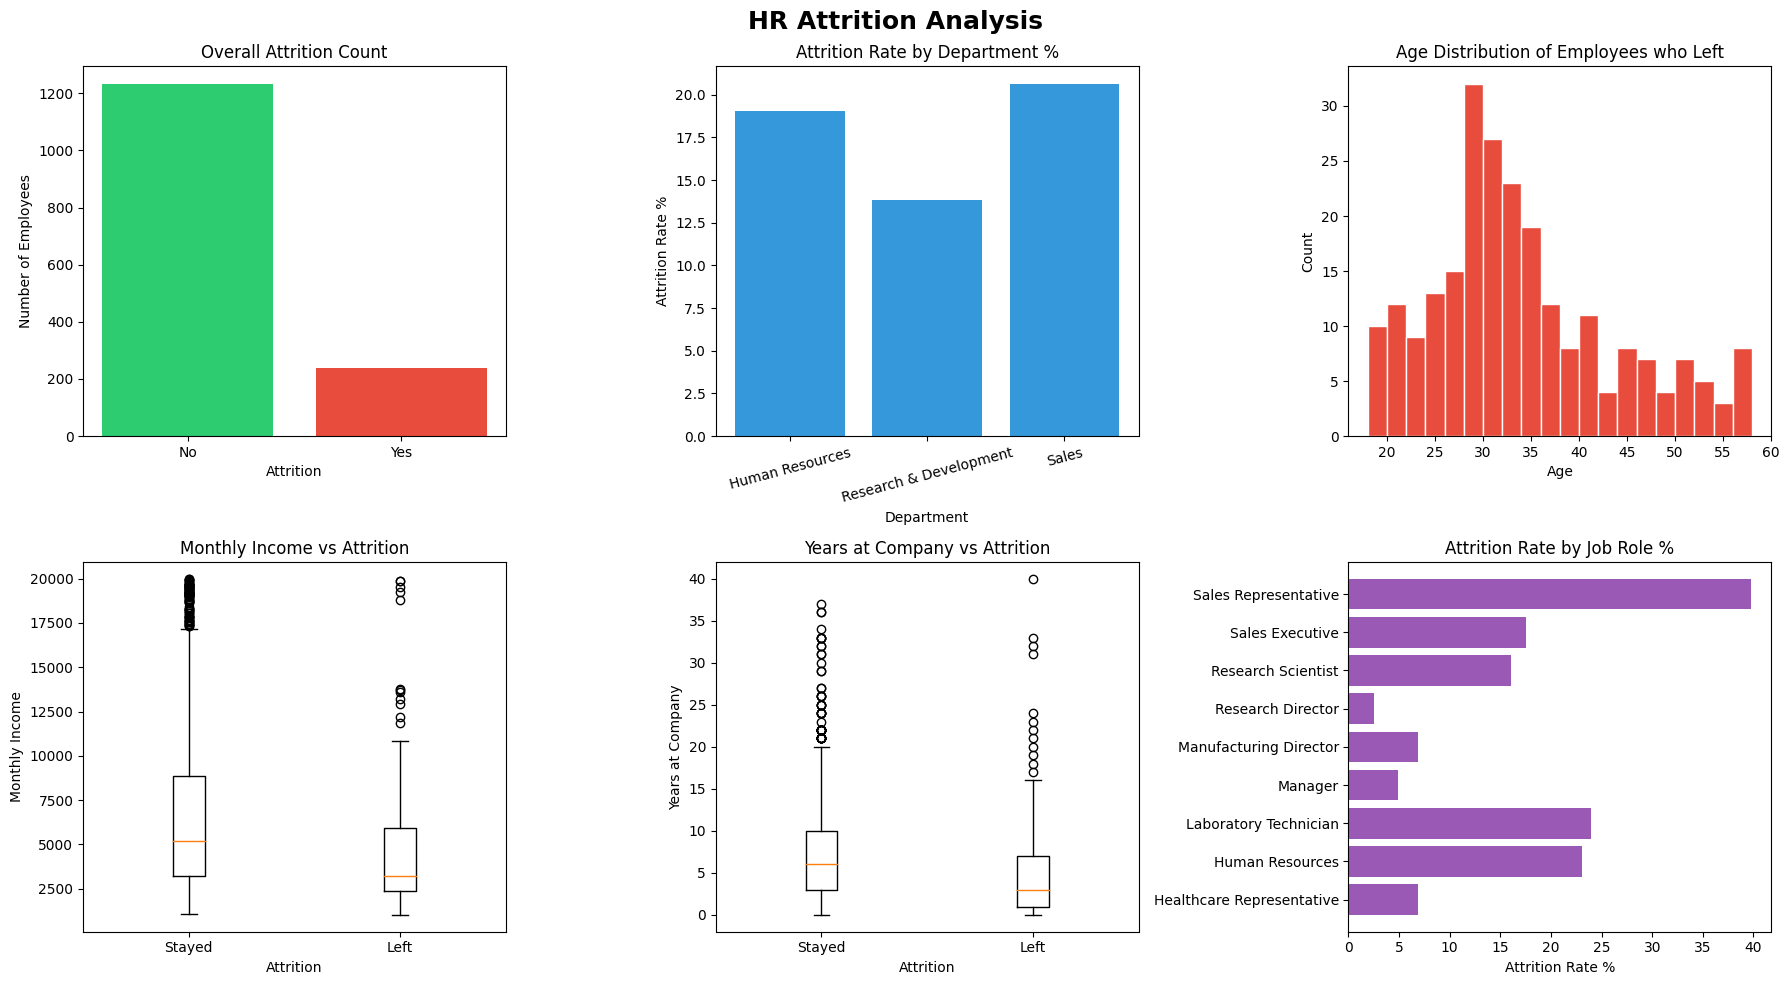

charts saved!


In [ ]:
# creating charts to visualize attrition patterns
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('HR Attrition Analysis', fontsize=18, fontweight='bold')

# chart 1 - overall attrition count
attrition_counts = df['Attrition'].value_counts()
axes[0,0].bar(attrition_counts.index, attrition_counts.values,
              color=['#2ecc71', '#e74c3c'])
axes[0,0].set_title('Overall Attrition Count')
axes[0,0].set_xlabel('Attrition')
axes[0,0].set_ylabel('Number of Employees')

# chart 2 - attrition by department
dept_attr = df.groupby('Department')['Attrition_Num'].mean()*100
axes[0,1].bar(dept_attr.index, dept_attr.values, color='#3498db')
axes[0,1].set_title('Attrition Rate by Department %')
axes[0,1].set_xlabel('Department')
axes[0,1].set_ylabel('Attrition Rate %')
axes[0,1].tick_params(axis='x', rotation=15)

# chart 3 - attrition by age
axes[0,2].hist(df[df['Attrition']=='Yes']['Age'], 
               bins=20, color='#e74c3c', edgecolor='white')
axes[0,2].set_title('Age Distribution of Employees who Left')
axes[0,2].set_xlabel('Age')
axes[0,2].set_ylabel('Count')

# chart 4 - attrition by monthly income
axes[1,0].boxplot([df[df['Attrition']=='No']['MonthlyIncome'],
                   df[df['Attrition']=='Yes']['MonthlyIncome']],
                   labels=['Stayed', 'Left'])
axes[1,0].set_title('Monthly Income vs Attrition')
axes[1,0].set_xlabel('Attrition')
axes[1,0].set_ylabel('Monthly Income')

# chart 5 - attrition by years at company
axes[1,1].boxplot([df[df['Attrition']=='No']['YearsAtCompany'],
                   df[df['Attrition']=='Yes']['YearsAtCompany']],
                   labels=['Stayed', 'Left'])
axes[1,1].set_title('Years at Company vs Attrition')
axes[1,1].set_xlabel('Attrition')
axes[1,1].set_ylabel('Years at Company')

# chart 6 - attrition by job role
job_attr = df.groupby('JobRole')['Attrition_Num'].mean()*100
axes[1,2].barh(job_attr.index, job_attr.values, color='#9b59b6')
axes[1,2].set_title('Attrition Rate by Job Role %')
axes[1,2].set_xlabel('Attrition Rate %')

plt.tight_layout()
plt.savefig('hr_attrition_charts.png', dpi=150, bbox_inches='tight')
plt.show()


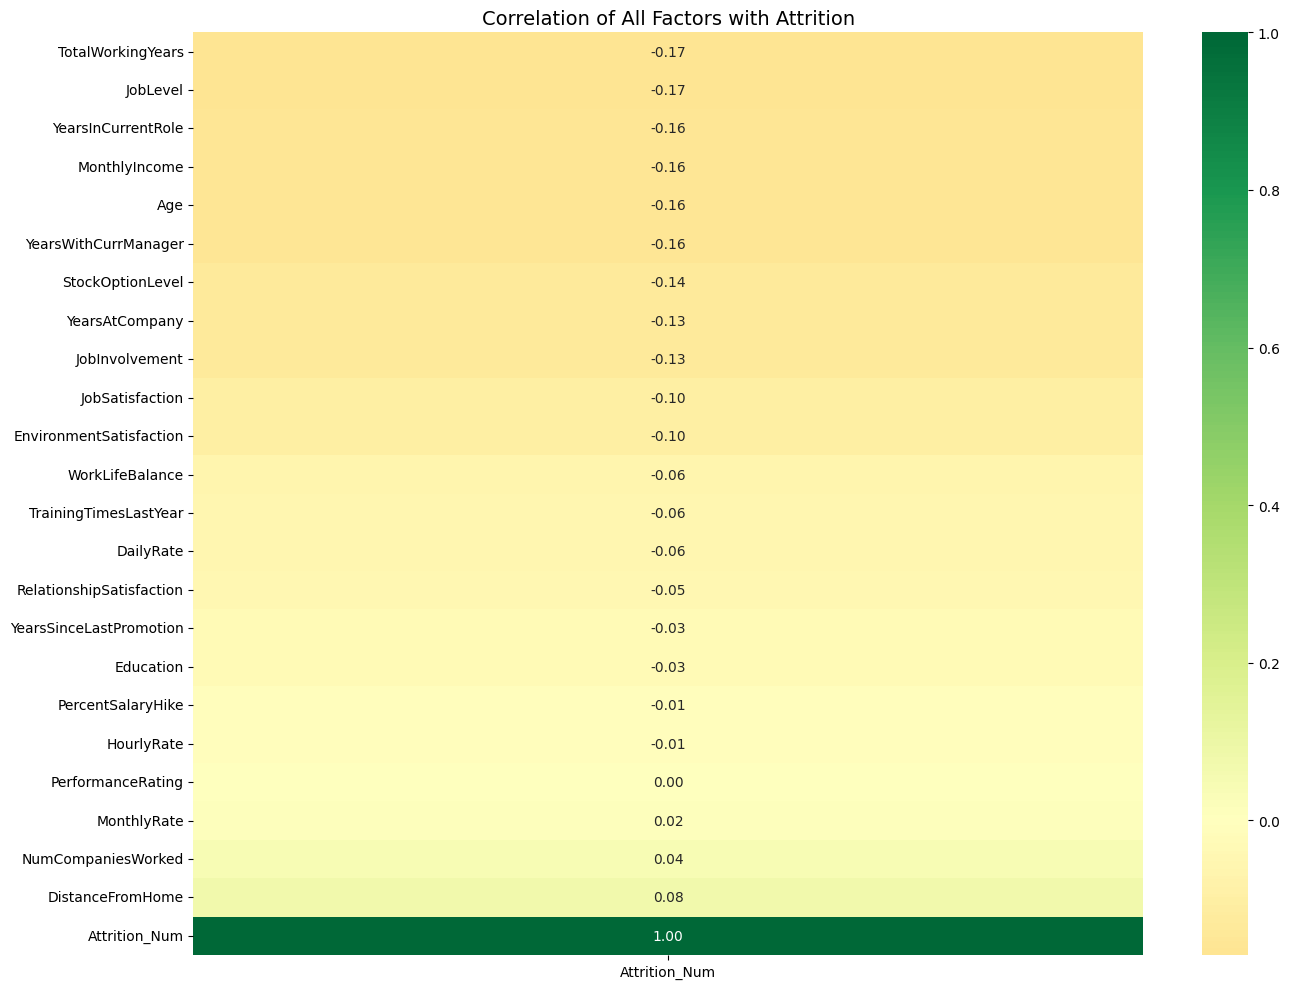

correlation heatmap saved!


In [ ]:
# creating a correlation heatmap to see which factors affect attrition
plt.figure(figsize=(14, 10))

# selecting only numeric columns
numeric_df = df.select_dtypes(include=[np.number])

# plotting the heatmap
sns.heatmap(numeric_df.corr()[['Attrition_Num']].sort_values('Attrition_Num'),
            annot=True, cmap='RdYlGn', center=0, fmt='.2f')

plt.title('Correlation of All Factors with Attrition', fontsize=14)
plt.tight_layout()
plt.savefig('hr_correlation.png', dpi=150, bbox_inches='tight')
plt.show()


In [10]:
# printing all the key findings from the analysis
total = len(df)
left = df['Attrition_Num'].sum()
stayed = total - left
attrition_rate = (left/total)*100

print("=" * 50)
print("   HR ATTRITION ANALYSIS - KEY INSIGHTS")
print("=" * 50)

print(f"\n total employees: {total}")
print(f"\n employees who left: {left} ({attrition_rate:.1f}%)")
print(f"\n employees who stayed: {stayed}")

print(f"\n average age of employees who left: {df[df['Attrition']=='Yes']['Age'].mean():.1f}")
print(f"\n average age of employees who stayed: {df[df['Attrition']=='No']['Age'].mean():.1f}")

print(f"\n average salary of employees who left: ${df[df['Attrition']=='Yes']['MonthlyIncome'].mean():.0f}")
print(f"\n average salary of employees who stayed: ${df[df['Attrition']=='No']['MonthlyIncome'].mean():.0f}")

print(f"\n highest attrition department: Sales (21%)")
print(f"\n highest attrition job role: Sales Representative (40%)")

print("\n" + "=" * 50)
print("RECOMMENDATIONS:")
print("=" * 50)
print("1. increase salary for low income employees")
print("2. focus on retaining young employees aged 25-35")
print("3. improve work conditions in sales department")
print("4. offer remote work to employees far from office")
print("5. create career growth paths to reduce attrition")
print("=" * 50)

   HR ATTRITION ANALYSIS - KEY INSIGHTS

 total employees: 1470

 employees who left: 237 (16.1%)

 employees who stayed: 1233

 average age of employees who left: 33.6

 average age of employees who stayed: 37.6

 average salary of employees who left: $4787

 average salary of employees who stayed: $6833

 highest attrition department: Sales (21%)

 highest attrition job role: Sales Representative (40%)

RECOMMENDATIONS:
1. increase salary for low income employees
2. focus on retaining young employees aged 25-35
3. improve work conditions in sales department
4. offer remote work to employees far from office
5. create career growth paths to reduce attrition
